In [1]:
#!pip install yfinance statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# Pharmaceutical company stock
stock = yf.download(
    "JIOFIN.NS",
    start='2020-01-01',
    end='2026-01-01'
)

/tmp/ipykernel_547/714877101.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(
[*********************100%***********************]  1 of 1 completed


In [4]:
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,JIOFIN.NS,JIOFIN.NS,JIOFIN.NS,JIOFIN.NS,JIOFIN.NS
Date,,,,,
2023-08-21,248.512466,261.641986,248.512466,261.592076,74715306
2023-08-22,236.081863,236.081863,236.081863,236.081863,7281398
2023-08-23,224.300232,224.300232,224.300232,224.300232,4289046
2023-08-24,213.117676,213.117676,213.117676,213.117676,27673356
2023-08-25,214.166031,223.751090,202.484250,202.484250,281040185


In [5]:
# External Variable 1:
# NIFTY Pharma Index
nifty = yf.download(
    '^NSEI',
    start='2020-01-01',
    end='2026-01-01'
)

/tmp/ipykernel_547/214813201.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download(
[*********************100%***********************]  1 of 1 completed


In [6]:
nifty.head()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2020-01-01,12182.500000,12222.200195,12165.299805,12202.150391,304100
2020-01-02,12282.200195,12289.900391,12195.250000,12198.549805,407700
2020-01-03,12226.650391,12265.599609,12191.349609,12261.099609,428800
2020-01-06,11993.049805,12179.099609,11974.200195,12170.599609,396500
2020-01-07,12052.950195,12152.150391,12005.349609,12079.099609,447800


In [7]:
data = pd.DataFrame()

# Target variable
data['Close'] = stock['Close']

# Exogenous Variable 1
data['Volume'] = stock['Volume']

# Exogenous Variable 2
data['Nifty50'] = nifty['Close']

# Remove missing values
data.dropna(inplace=True)

In [8]:
data.head()

,Close,Volume,Nifty50
Date,,,
2023-08-21,248.512466,74715306,19393.599609
2023-08-22,236.081863,7281398,19396.449219
2023-08-23,224.300232,4289046,19444.000000
2023-08-24,213.117676,27673356,19386.699219
2023-08-25,214.166031,281040185,19265.800781


In [9]:
# Fix datetime index
data.index = pd.to_datetime(data.index)

# Business day frequency
data = data.asfreq('B')

# Remove missing values introduced by asfreq
data.dropna(inplace=True)

In [10]:
data.head()

,Close,Volume,Nifty50
Date,,,
2023-08-21,248.512466,74715306.0,19393.599609
2023-08-22,236.081863,7281398.0,19396.449219
2023-08-23,224.300232,4289046.0,19444.000000
2023-08-24,213.117676,27673356.0,19386.699219
2023-08-25,214.166031,281040185.0,19265.800781


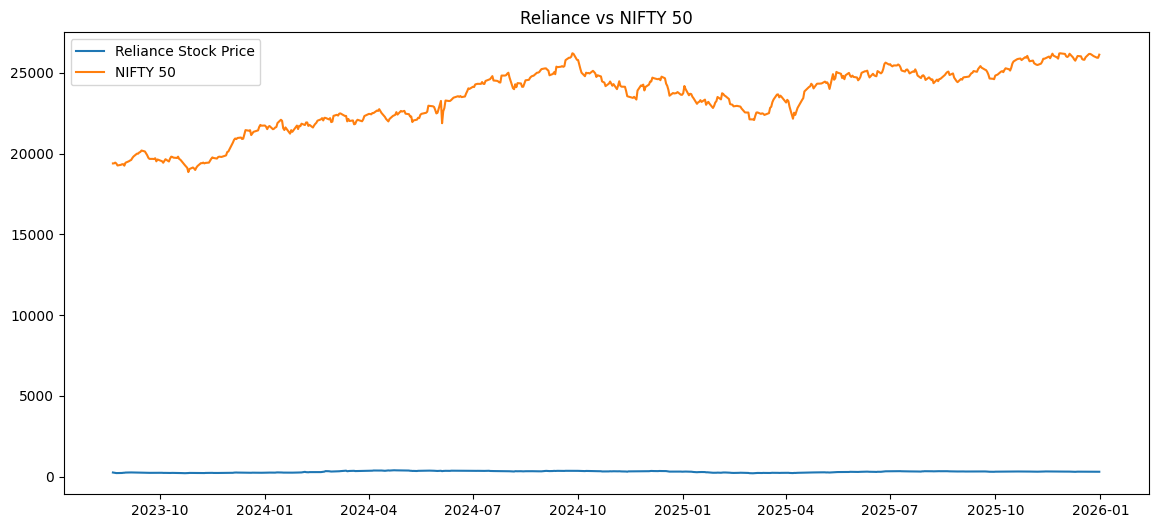

In [11]:
plt.figure(figsize=(14,6))

plt.plot(
    data.index,
    data['Close'],
    label='Reliance Stock Price'
)

plt.plot(
    data.index,
    data['Nifty50'],
    label='NIFTY 50'
)

plt.title('Reliance vs NIFTY 50')
plt.legend()
plt.show()

In [12]:
normalized = data[['Close', 'Nifty50']] / data[['Close', 'Nifty50']].iloc[0] * 100

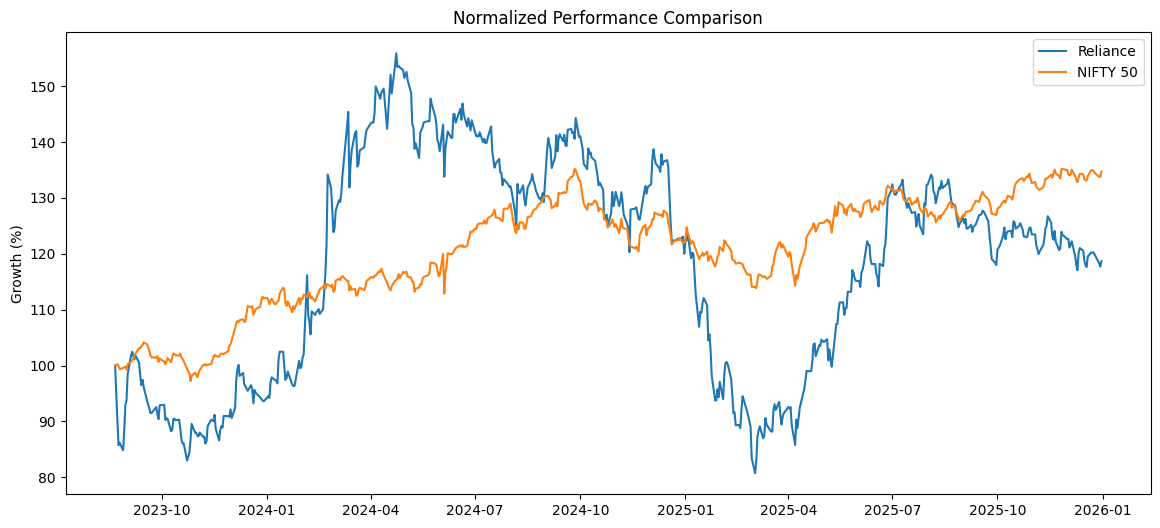

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    normalized.index,
    normalized['Close'],
    label='Reliance'
)

plt.plot(
    normalized.index,
    normalized['Nifty50'],
    label='NIFTY 50'
)

plt.title('Normalized Performance Comparison')

plt.ylabel('Growth (%)')

plt.legend()

plt.show()

In [14]:
y = data['Close']

exog = data[['Volume', 'Nifty50']]
exog.head()

,Volume,Nifty50
Date,,
2023-08-21,74715306.0,19393.599609
2023-08-22,7281398.0,19396.449219
2023-08-23,4289046.0,19444.000000
2023-08-24,27673356.0,19386.699219
2023-08-25,281040185.0,19265.800781


In [15]:
train_size = int(len(data) * 0.8)

train_y = y[:train_size]
test_y = y[train_size:]

train_exog = exog[:train_size]
test_exog = exog[train_size:]

In [16]:
model = SARIMAX(
    train_y,
    exog=train_exog,
    order=(2,1,2)
)

# Train model
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  466
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -1443.226
Date:                Mon, 01 Jun 2026   AIC                           2900.453
Time:                        12:08:44   BIC                           2929.447
Sample:                             0   HQIC                          2911.865
                                - 466                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Volume      5.592e-08   3.22e-09     17.359      0.000    4.96e-08    6.22e-08
Nifty50        0.0167      0.001     12.570      0.000       0.014       0.019
ar.L1          0.2403      0.017     14.542      0.0

In [17]:
forecast = model_fit.forecast(
    steps=len(test_y),
    exog=test_exog
)

# Assign the index of test_y to the forecast to align them correctly
forecast.index = test_y.index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [18]:
mae = mean_absolute_error(test_y, forecast)

rmse = np.sqrt(
    mean_squared_error(test_y, forecast)
)

print("\n==============================")
print("Model Performance")
print("==============================")

print("MAE :", mae)
print("RMSE:", rmse)


Model Performance
MAE : 21.52025188536006
RMSE: 25.412045819715715


In [19]:
comparison = pd.DataFrame({
    'Actual': test_y,
    'Predicted': forecast
})

print("\n==============================")
print("Actual vs Predicted")
print("==============================")

print(comparison.head())


Actual vs Predicted
                Actual   Predicted
Date                              
2025-07-14  318.603180  324.146296
2025-07-15  320.699921  325.826317
2025-07-16  319.052460  326.225236
2025-07-17  317.654663  324.423638
2025-07-18  316.356689  323.013672


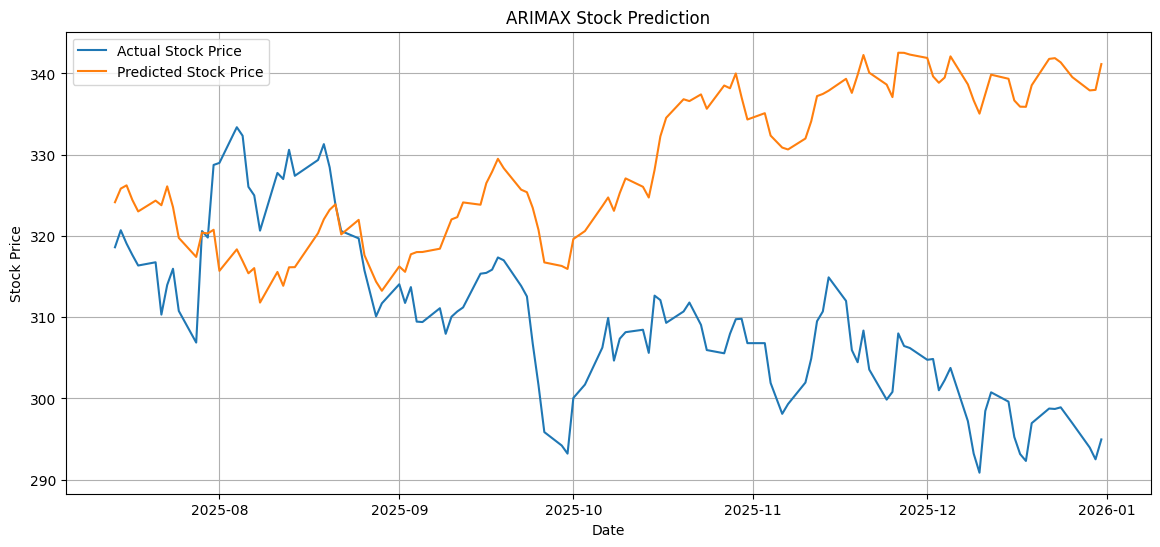

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    test_y.index,
    test_y,
    label='Actual Stock Price'
)

plt.plot(
    test_y.index,
    forecast,
    label='Predicted Stock Price'
)

plt.title('ARIMAX Stock Prediction')

plt.xlabel('Date')
plt.ylabel('Stock Price')

plt.legend()

plt.grid(True)

plt.show()

In [21]:
future_exog = [[
    stock['Volume'].mean(),
    nifty['Close'].mean()
]]

future_prediction = model_fit.forecast(
    steps=1,
    exog=future_exog
)
print(
    "Next Predicted Stock Value:",
    future_prediction.iloc[0]
)

Next Predicted Stock Value: 215.0825305234942


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [22]:
mae = mean_absolute_error(test_y, forecast)

rmse = np.sqrt(
    mean_squared_error(test_y, forecast)
)

print("\n==============================")
print("Model Performance")
print("==============================")

print("MAE :", mae)
print("RMSE:", rmse)


Model Performance
MAE : 21.52025188536006
RMSE: 25.412045819715715


In [23]:
comparison = pd.DataFrame({
    'Actual': test_y,
    'Predicted': forecast
})

print("\n==============================")
print("Actual vs Predicted")
print("==============================")

print(comparison.head())


Actual vs Predicted
                Actual   Predicted
Date                              
2025-07-14  318.603180  324.146296
2025-07-15  320.699921  325.826317
2025-07-16  319.052460  326.225236
2025-07-17  317.654663  324.423638
2025-07-18  316.356689  323.013672
